##  A library for data loaders.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import copy
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from typing import Dict
from torch.utils.data import IterableDataset
import warnings


import datatable as dt
import numpy as np
import pandas as pd
import torch
import torch_geometric.transforms as T
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset
from torch_geometric.data import Data
from torch_geometric.datasets import Planetoid, WebKB, WikipediaNetwork
from torch_geometric.nn import GAE, VGAE, GCNConv
from torch_geometric.seed import seed_everything as th_seed
from typing import Any, Dict, List, Tuple



from utils.utils import set_dirs, update_config_with_model_dims
#from utils.model import NESS
from utils.loss_functions import  JointLoss

In [2]:
#In this cell there some class and function for loading dataset and preprocessing

class GraphLoader:
    """
    Data loader class for graph data.
    """

    def __init__(self, config: Dict[str, Any], dataset_name: str, kwargs: Dict[str, Any] = {}) -> None:
        """
        Initializes the GraphLoader.

        Parameters
        ----------
        config : Dict[str, Any]
            Dictionary containing options and arguments.
        dataset_name : str
            Name of the dataset to load.
        kwargs : Dict[str, Any], optional
            Dictionary for additional parameters if needed, by default {}.
        """
        # Get config
        self.config = config
        # Set the seed
        th_seed(config["seed"])
        # Set the paths
        paths = config["paths"]
        # data > dataset_name
        file_path = os.path.join(paths["data"], dataset_name)
        # Get the datasets
        self.train_data, self.validation_data, self.test_data = self.get_dataset(dataset_name, file_path)        
        

    def get_dataset(self, dataset_name: str, file_path: str) -> Tuple[Data, Data, Data]:
        """
        Returns the training, validation, and test datasets.

        Parameters
        ----------
        dataset_name : str
            Name of the dataset to load.
        file_path : str
            Path to the dataset.

        Returns
        -------
        Tuple[Data, Data, Data]
            Training, validation, and test datasets.
        """

        # Initialize Graph dataset class
        graph_dataset = GraphDataset(self.config, datadir=file_path, dataset_name=dataset_name)
        
        # Load Training, Validation, Test datasets
        train_data, val_data, test_data = graph_dataset._load_data()
        
        # Generate static subgraphs from training set
        train_data = self.generate_subgraphs(train_data)
  
        # Return
        return train_data, val_data, test_data
    
    
    def generate_subgraphs(self, train_data: Data) -> List[Data]:
        """
        Generates subgraphs from the training data.

        Parameters
        ----------
        train_data : Data
            Training data containing the graph.

        Returns
        -------
        List[Data]
            List of subgraphs generated from the training data.
        """
        # Initialize list to hold subgraphs
        subgraphs = [train_data]

        # Check if we are generating subgraphs from the graph. If False, we are in standard GAE mode
        if self.config["n_subgraphs"] > 1:
                
            # Generate subgraphs
            for i in range(self.config["n_subgraphs"]):
                
                # Change random seed
                th_seed(i)
                
                partition = 1.0/(self.config["n_subgraphs"]-i)
                
                # For the last subgraph, get 95% of the remaining graph. if num_val=1.0, RandomLinkSplit will raise error
                if partition == 1.0:
                    partition = 0.95
                    
                random_link_split = T.RandomLinkSplit(num_val=partition, 
                                                      num_test=0, 
                                                      is_undirected=True, 
                                                      split_labels=True, 
                                                      add_negative_train_samples=False)

                # get a subgraph from training data
                train_data, train_subgraph, _ = random_link_split(train_data)
                
                # Make sure that we are using only the nodes within the subgraph by overwriting the edge index 
                # with positive edge index + positive edge index reversed in direction (to make it undirected)
                pos_swapped = train_subgraph.pos_edge_label_index[[1,0],:] 
                train_subgraph.edge_index = torch.cat((train_subgraph.pos_edge_label_index, pos_swapped), dim=1)
                
                # Remove negative edge attributes. We want to sample negative samples during training
                # Masks are also not needed
                if hasattr(train_subgraph, "neg_edge_label_index"):
                    delattr(train_subgraph, "neg_edge_label_index")
                    delattr(train_subgraph, "neg_edge_label")
                    
                if hasattr(train_subgraph, "train_mask"):
                    delattr(train_subgraph, "train_mask")
                    delattr(train_subgraph, "val_mask")
                    delattr(train_subgraph, "test_mask")


                # store the sampled subgraph
                subgraphs = [train_subgraph] + subgraphs
                       
        # Change random seed back to original
        th_seed(self.config["seed"])
        
        # Return all subgraphs and original larger graph
        return subgraphs

    
def get_transform(options):
    """Splits data to train, validation and test, and moves them to the device"""
    transform = T.Compose([
        T.NormalizeFeatures(),
        T.ToDevice(options["device"]),
        T.RandomLinkSplit(num_val=0.05, 
                          num_test=0.15, 
                          is_undirected=True,
                          split_labels=True, 
                          add_negative_train_samples=False),
        ])
        
    return transform


class GraphDataset:
    """
    Dataset class for graph data format.
    """

    def __init__(self, config: Dict[str, Any], datadir: str, dataset_name: str) -> None:
        """
        Initializes the GraphDataset.

        Parameters
        ----------
        config : Dict[str, Any]
            Dictionary containing options and arguments.
        datadir : str
            The path to the data directory.
        dataset_name : str
            Name of the dataset to load.
        """
        self.config = config
        self.paths = config["paths"]
        self.dataset_name = dataset_name
        self.data_path = os.path.join(self.paths["data"], 'Planetoid')
        self.transform = get_transform(config)

        
    def _load_data(self) -> Tuple[Data, Data, Data]:
        """
        Loads one of many available datasets and returns features and labels.

        Returns
        -------
        Tuple[Data, Data, Data]
            Training, validation, and test datasets.
        """
        if self.dataset_name.lower() in ['cora', 'citeseer', 'pubmed']:
            # Get the dataset
            dataset = Planetoid(self.data_path, self.dataset_name, split="random", transform = self.transform)
        elif  self.dataset_name.lower() in ['chameleon']:
            # Get the dataset
            dataset = WikipediaNetwork(root=self.data_path, name=self.dataset_name, transform = self.transform)
        elif  self.dataset_name.lower() in ["cornell", "texas", "wisconsin"]:
            # Get the dataset
            dataset = WebKB(root=self.data_path, name=self.dataset_name, transform = self.transform) 
        else:
            print(f"Given dataset name is not found. Check for typos, or missing condition ")
            exit()
            
        # Data splits
        train_data, val_data, test_data = dataset[0]
        
        # Return
        return train_data, val_data, test_data


In [3]:

#Loads arguments and configuration for GNN-based encoder used in NESS.


import os
import pprint
from argparse import ArgumentParser
from os.path import abspath, dirname

import torch

from utils.utils import get_runtime_and_model_config, print_config


def get_arguments():
    # Initialize parser
    parser = ArgumentParser()
    # Dataset can be provided via command line
    parser.add_argument("-d", "--dataset", type=str, default="cora")
    # Encoder type
    parser.add_argument("-gnn", "--gnn", type=str, default="GNAE")
    # Random seed
    parser.add_argument("-seed", "--seed", type=int, default=57)
    # Whether to use contrastive loss
    parser.add_argument("-cl", "--cl", type=bool, default=False)
    # Whether to add noise to input
    parser.add_argument("-an", "--an", type=bool, default=True)
    # Whether to use GPU.
    parser.add_argument("-g", "--gpu", dest='gpu', action='store_true', 
                        help='Used to assign GPU as the device, assuming that GPU is available')
    
    parser.add_argument("-ng", "--no_gpu", dest='gpu', action='store_false', 
                        help='Used to assign CPU as the device')
    parser.set_defaults(gpu=True)
    
    # GPU device number as in "cuda:0". Defaul is 0.
    parser.add_argument("-dn", "--device_number", type=str, default='0', 
                        help='Defines which GPU to use. It is 0 by default')
    
    ### Set parameter for L2-Regularization ##****************
    parser.add_argument("-reg", "--l2_reg", type=float, default='0', 
                        help='Defines which GPU to use. It is 0 by default')
    
    # Experiment number
    parser.add_argument("-ex", "--experiment", type=int, default=1)
    # Load model saved at specific epoch
    parser.add_argument("-m", "--model_at_epoch", type=int, default=None)
    
    # Return parser arguments along with the unknown ones
    args, unknown = parser.parse_known_args()
    return args


def get_config(args):
    # Load runtime config from config folder: ./config/
    config = get_runtime_and_model_config(args)
    # Define which device to use: GPU or CPU
    config["device"] = torch.device('cuda:'+args.device_number if torch.cuda.is_available() and args.gpu else 'cpu')
    # Model at specific epoch
    config["model_at_epoch"] = args.model_at_epoch
    # Indicate which device is being used
    config["l2_reg"]=args.l2_reg
    print(f"Device being used is {config['device']}")
    # Return
    return config

def print_config_summary(config, args=None):
    """Prints out summary of options and arguments used"""
    # Summarize config on the screen as a sanity check
    print(100 * "=")
    print(f"Here is the configuration being used:\n")
    print_config(config)
    print(100 * "=")
    if args is not None:
        print(f"Arguments being used:\n")
        print_config(args)
        print(100 * "=")


In [4]:
# Get parser / command line arguments
args = get_arguments()
# Get configuration file
config = get_config(args)


# By default, we are using the name of the dataset. This can be customized.
config["experiment"] = config["dataset"]

# File name to use when saving results as csv. This can be customized
config["file_name"] = config["experiment"] + "_sub" + str(config["n_subgraphs"]) + '_seed' + str(config["seed"])

Device being used is cpu


In [5]:
# Summarize config and arguments on the screen as a sanity check
print_config_summary(config, args)


Here is the configuration being used:

+-------------------+----------------------------------------------+
|     Parameter     |                    Value                     |
+===================+==============================================+
| Add noise         | True                                         |
+-------------------+----------------------------------------------+
| Aggregation       | mean                                         |
+-------------------+----------------------------------------------+
| Batch size        | 128                                          |
+-------------------+----------------------------------------------+
| Contrastive loss  | False                                        |
+-------------------+----------------------------------------------+
| Cosine similarity | False                                        |
+-------------------+----------------------------------------------+
| Dataset           | cora                                      

o add L2 regularization to your NESS class, you can modify the optimizer to include a weight_decay parameter, which applies L2 regularization. In PyTorch, the weight_decay parameter of optimizers such as AdamW and SGD is used to apply L2 regularization directly during the optimization step.

Here's how you can modify the _adam method to include weight_decay:

In [6]:
# NESS class, the framework used to learn node embeddings from static subgraphs.


import csv
import gc
import itertools
import os
import time

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import torch_geometric.transforms as T
from torch_geometric.seed import seed_everything as th_seed
from torch_geometric.utils import dropout_adj
from torch_geometric.data import Data

from tqdm import tqdm
from typing import Dict, List, Union, Tuple, Optional

from utils.loss_functions import JointLoss
from utils.model_plot import save_auc_plot, save_loss_plot
from utils.model_utils import GAEWrapper
from utils.utils import set_dirs, set_seed

torch.autograd.set_detect_anomaly(True)

class NESS:
    """
    Model: Trains a Graph Autoencoder with a Projection network, using NESS framework.
    """

    def __init__(self, config: Dict):
        """Initializes the NESS class.

        Parameters
        ----------
        config : dict
            Configuration dictionary with parameters for training a Graph Autoencoder 
            using NESS framework.
        """
        # Get config
        self.config = config
        # Set L2-Regularization Parameters******************
        self.l2_reg=config["l2_reg"]
        
        # Define which device to use: GPU, or CPU
        self.device = config["device"]
        # Create empty lists and dictionary
        self.model_dict, self.summary = {}, {}
        # Set random seed
        set_seed(self.config)
        # Set paths for results and initialize some arrays to collect data during training
        self._set_paths()
        # Set directories i.e. create ones that are missing.
        set_dirs(self.config)
        # ------Network---------
        # Instantiate networks
        print("Building the models for training and evaluation in NESS framework...")
        # Set Autoencoders i.e. setting loss, optimizer, and device assignment (GPU, or CPU)
        self.set_autoencoder()
        # Set scheduler (its use is optional)
        self._set_scheduler()
        # Print out model architecture
        self.print_model_summary()
        

        
    def set_autoencoder(self) -> None:
        """Sets up the autoencoder model, optimizer, and loss.
        
        This function is responsible for initializing the Graph Autoencoder, setting up 
        the optimizer, and defining the joint loss.
        """   
        # Instantiate the model for the text Autoencoder
        self.autoencoder = GAEWrapper(self.config)
        # Add the model and its name to a list to save, and load in the future
        self.model_dict.update({"autoencoder": self.autoencoder})
        # Assign autoencoder to a device
        for _, model in self.model_dict.items(): model.to(self.device)
        # Get model parameters
        parameters = [model.parameters() for _, model in self.model_dict.items()]
        # Joint loss including contrastive, reconstruction and distance losses
        
        
    
        
        self.joint_loss = None if self.config["dataset"][:4] == "ogbl" else JointLoss(self.config)
        # Set optimizer for autoencoder
        
        # Set optimizer for autoencoder with L2 regularization
        self.optimizer_ae = self._adam(parameters, lr=self.config["learning_rate"], weight_decay=self.config["l2_reg"])
        ##  self.optimizer_ae = self._adam(parameters, lr=self.config["learning_rate"])
        
        # Add items to summary to be used for reporting later
        self.summary.update({"recon_loss": []})

    def set_parallelism(self, model) -> None:
        """Sets up parallelism in training if multiple GPUs are available.

        Parameters
        ----------
        model : torch.nn.Module
            The model for which the parallelism is to be set.

        Returns
        -------
        model : torch.nn.Module
            The input model wrapped in DataParallel if multiple GPUs are available.
        """
        # If we are using GPU, and if there are multiple GPUs, parallelize training
        if torch.cuda.is_available() and torch.cuda.device_count() > 1:
            print(torch.cuda.device_count(), " GPUs will be used!")
            model = torch.nn.DataParallel(model)
        return model

    def fit(self, data_loader: DataLoader) -> None:
        """Fits model to the data.

        Parameters
        ----------
        data_loader : DataLoader
            The DataLoader object that provides the data.
        """
        
        # Get data loaders
        train_data = data_loader.train_data
        validation_data = data_loader.validation_data
        test_data = data_loader.test_data

        # Placeholders to record losses per batch
        self.metrics = {"tloss_e": [], "vloss_e": [], "rloss_e": [], "zloss_e": [], "val_auc": [], "tr_auc": []}
        self.val_auc = "NA"
        self.tr_auc = "NA"

        # Turn on training mode for the model.
        self.set_mode(mode="training")

        # Reset best test auc
        self.best_val_auc = 0
        self.best_epoch = 0
        self.patient = 0

        
        # Start joint training of Autoencoder with Projection network
        for epoch in range(1,50):
            
            # Keep a record of epoch
            self.epoch = epoch
            
            # 0 - Update Autoencoder
            self.update_autoencoder(train_data)
            
            # 1 - Update log message using epoch and batch numbers
           
            if epoch % 40 == 0:
                   self.update_log(epoch)
            
            # 2 - Clean-up for efficient memory usage.
            gc.collect()                
                
            # 3 - Run Validation
            self.run_validation(train_data, validation_data)

            # 4 - Change learning rate if scheduler==True
            _ = self.scheduler.step() if self.config["scheduler"] else None
            
            # 5 - Stop training if we run out of patience
            if self.patient == self.config["patience"]:
                break
            
        # Get the test performance and computing inference time 
       
        start = time.time()
        self.test_auc, self.test_ap = self.autoencoder.single_test(train_data, test_data)
        end = time.time()
        self.t_inference= end-start

        # Save plots of training loss and validation auc
        save_loss_plot(self.metrics, self._plots_path)
        save_auc_plot(self.metrics, self._plots_path)
        
        # Convert loss dictionary to a dataframe
        loss_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in self.metrics.items()]))
        
        # Save loss dataframe as csv file for later use
        loss_df.to_csv(self._loss_path + "/losses.csv")
        
            
    def run_validation(self, train_data: Union[List, torch.Tensor], validation_data: Union[List, torch.Tensor]) -> None:
        """Runs validation on the trained model and save weights if validation AUC improves.

        Parameters
        ----------
        train_data : List or torch.Tensor
            The training dataset.

        validation_data : List or torch.Tensor
            The validation dataset.
        """
        
        # Set the evaluation mode
        self.set_mode(mode="evaluation")
        
        # Validate every nth epoch. n=1 by default, but it can be changed in the config file
        if self.config["validate"]:

            # Compute validation AUCs
            self.val_auc, _ = self.autoencoder.single_test(train_data, validation_data)
                
            # Append auc's to the list to use for plots
            self.metrics["val_auc"].append(self.val_auc)
                
        # Save intermediate model on regular intervals
        if self.epoch >=self.config["nth_epoch"] and self.epoch % self.config["nth_epoch"] == 0:
            
            # Check the test auc at this epoch
            self.config["model_at_epoch"] = self.epoch
            val_auc, _ = self.autoencoder.single_test(train_data, validation_data)

            # Update the metrics.
            if val_auc > self.best_val_auc:
                self.best_val_auc = val_auc
                self.best_epoch = self.epoch 
                self.save_weights()
                self.patient = 0
            else:
                self.patient += 1
                    
        # Set training mode back
        self.set_mode(mode="training")
    

    def update_autoencoder(self, subgraphs: List[Data]) -> None:
        """Updates autoencoder model.

        Parameters
        ----------
        subgraphs : list of Data
            A list that contains subgraphs + original training graph.
        """
        total_loss, contrastive_loss, recon_loss, zrecon_loss = [], [], [], []
        
        # Last element of the list is the original whole training graph
        graph = subgraphs[-1]
        
        # If len(subgraphs) > 1, it means that we sampled subgraphs from the graph. Else, we have a standard GAE
        subgraphs = subgraphs[:-1] if len(subgraphs) > 1 else subgraphs
        
        # A list to hold list of latents --- will be used to compute contrastive loss
        z_list = []
        
        # Initialize total loss
        tloss = None
        
        # pass subgraphs through model to reconstruct the original graph from subgraphs
        for sg in subgraphs:
            
            # Reference graph
            ref_graph = graph if self.config["full_graph"] else sg
                        
            # Drop edges if True
            if self.config["add_noise"]:
                sg.edge_index, sg.edge_attr = dropout_adj(sg.edge_index, edge_attr= sg.edge_attr, p=self.config["p_noise"])
            
            # Forwards pass
            z, latent = self.autoencoder(sg.x, sg.edge_index)           

            # Reconstruction loss by using GAE's native function
            rloss = self.autoencoder.gae.recon_loss(latent, ref_graph.pos_edge_label_index)
            
            # If the model is a variational model
            if self.autoencoder.variational:
                rloss = rloss + (1 / ref_graph.num_nodes) * self.autoencoder.gae.kl_loss()
            
            # Store z to the list
            z_list.append(z)
            
            # total loss
            tloss = tloss + rloss if tloss  is not None else rloss
            
            # Accumulate losses
            total_loss.append(tloss)
            recon_loss.append(rloss)
            
        # Clean up
        del rloss, tloss
        gc.collect()

        # Compute the losses
        n = len(total_loss)
        total_loss = sum(total_loss) / n
        recon_loss = sum(recon_loss) / n
        
        # If the graph is large such as pubmed, push the losses to cpu.
        if self.config["dataset"] == "pubmed":
            total_loss = total_loss.cpu()
            recon_loss = recon_loss.cpu()
            
        # Initiliaze contrastive loss
        closs = None
        zloss = None
        
        if self.config["contrastive_loss"] and len(subgraphs)>1:
                    
            # Generate combinations of z's to compute contrastive loss
            z_combinations = self.get_combinations_of_subgraphs(z_list)
            
            # Compute the contrastive loss for each pair of latent vectors
            for z in z_combinations:
                # Contrastive loss
                zloss = self.joint_loss(z)
                
                # Total contrastive loss
                closs = closs + zloss if closs is not None else zloss

            # Mean constrative loss
            closs = closs/len(z_combinations)
        
        # Update total loss
        total_loss = total_loss + closs if closs is not None else total_loss
        
        # Record losses
        self.metrics["tloss_e"].append(total_loss.item())
        self.metrics["rloss_e"].append(recon_loss.item())
        self.metrics["zloss_e"].append(closs.item() if closs is not None else 0)
        
        # Update Autoencoder params
        self._update_model(total_loss, self.optimizer_ae, retain_graph=True)
        
        # Delete loss and associated graph for efficient memory usage
        del total_loss, recon_loss, closs, zloss
        gc.collect()


    def get_combinations_of_subgraphs(self, z_list: List[Data]) -> List[Tuple[Data, Data]]:
        """Generates a list of combinations of subgraphs from the list of subgraphs.

        Parameters
        ----------
        z_list : list of Data
            List of subgraphs e.g. [z1, z2, z3, ...]

        Returns
        -------
        list of tuple
            A list of combinations of subgraphs e.g. [(z1, z2), (z1, z3), ...]
        """                            
        # Compute combinations of subgraphs [(z1, z2), (z1, z3)...]
        subgraph_combinations = list(itertools.combinations(z_list, 2))
        # List to store the concatenated subgraphs
        concatenated_subgraphs_list = []
        
        # Go through combinations
        for (zi, zj) in subgraph_combinations:
            # Concatenate xi, and xj, and turn it into a tensor
            z = torch.cat((zi, zj), dim=0)
            
            # Add it to the list
            concatenated_subgraphs_list.append(z)
        
        # Return the list of combination of subgraphs
        return concatenated_subgraphs_list
    
    def clean_up_memory(self, losses: List) -> None:
        """Deletes losses with attached graph, and cleans up memory.

        Parameters
        ----------
        losses : list
            List of loss values to be deleted.
        """
        for loss in losses: del loss
        gc.collect()

    def update_log(self, epoch: int) -> None:
        """Updates the messages displayed during training and evaluation.

        Parameters
        ----------
        epoch : int
            The current epoch number.
        """
        # For the first epoch, add losses for batches since we still don't have loss for the epoch
        if epoch < 1:
            description = f"Epoch:[{epoch - 1}], Total loss:{self.metrics['tloss_e'][-1]:.4f}"
            description += f", X recon loss:{self.metrics['rloss_e'][-1]:.4f}"
            if self.config["contrastive_loss"]:
                description += f", contrastive loss:{self.metrics['zloss_e'][-1]:.6f}"
            description += f", val auc:{self.val_auc}"

        # For sub-sequent epochs, display only epoch losses.
        else:
            description = f"Epoch:[{epoch - 1}] training loss:{self.metrics['tloss_e'][-1]:.4f}"
            description += f", X recon loss:{self.metrics['rloss_e'][-1]:.4f}"
            if self.config["contrastive_loss"]:
                description += f", contrastive loss:{self.metrics['zloss_e'][-1]:.6f}"
            # Add validation auc
            description += f", val auc:{self.val_auc}"

        # Update the displayed message
        print(description)

    def set_mode(self, mode: str = "training") -> None:
        """Sets the mode of the models, either as .train(), or .eval().

        Parameters
        ----------
        mode : str, optional
            Mode in which to set the models, by default "training".
        """
        for _, model in self.model_dict.items():
            model.train() if mode == "training" else model.eval()

    def save_weights(self, with_epoch: bool = False) -> None:
        """Saves weights of the models.

        Parameters
        ----------
        with_epoch : bool, optional
            If True, includes the epoch number in the filename, by default False.
        """
        for model_name in self.model_dict:
            
            # Check if we want to save the model at a specific epoch
            file_name = model_name + "_" + str(self.epoch) if with_epoch else model_name
            
            # Save the model
            torch.save(self.model_dict[model_name], self._model_path + "/" + file_name + ".pt")
        
        print("Done with saving models.")

    def load_models(self, epoch: Optional[int] = None) -> None:
        """Loads weights saved at the end of the training.

        Parameters
        ----------
        epoch : int, optional
            If provided, loads the weights saved at the specified epoch, by default None.
        """
        for model_name in self.model_dict:
            
            # Check if we want to load the model saved at a specific epoch
            file_name = model_name + "_" + str(epoch) if epoch is not None else model_name

            # Load the model
            model = torch.load(self._model_path + "/" + file_name + ".pt", map_location=self.device)
            
            # Register model to the class
            setattr(self, model_name, model.eval())
            print(f"--{model_name} is loaded")
        
        print("Done with loading models.")

    def print_model_summary(self) -> None:
        """Displays model architectures as a sanity check to see if the models are constructed correctly."""
        # Summary of the model
        description = f"{40 * '-'}Summary of the models:{40 * '-'}\n"
        description += f"{34 * '='} NESS Architecture {34 * '='}\n"
        description += f"{self.autoencoder}\n"
        # Print model architecture
        print(description)

    def _update_model(self, loss: torch.Tensor, optimizer: torch.optim.Optimizer, retain_graph: bool = True) -> None:
        """Does backpropagation and updates the model parameters.

        Parameters
        ----------
        loss : torch.Tensor
            Loss containing computational graph.

        optimizer : torch.optim.Optimizer
            Optimizer used during training.

        retain_graph : bool, optional
            If True, retains the computational graph after backpropagation, by default True.
        """
        # Reset optimizer
        optimizer.zero_grad()
        # Backward propagation to compute gradients
        loss.backward(retain_graph=retain_graph)
        # Update weights
        optimizer.step()

    def _set_scheduler(self) -> None:
        """Sets a scheduler for the learning rate of the autoencoder."""
        # Set scheduler (Its use will be optional)
        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer_ae, step_size=1, gamma=0.99)

    def _set_paths(self) -> None:
        """Sets paths to be used for saving results at the end of the training."""
        # Top results directory
        self._results_path = os.path.join(self.config["paths"]["results"], self.config["experiment"])
        # Directory to save model
        self._model_path = os.path.join(self._results_path, "training", "model")
        # Directory to save plots as png files
        self._plots_path = os.path.join(self._results_path, "training", "plots")
        # Directory to save losses as csv file
        self._loss_path = os.path.join(self._results_path, "training", "loss")

    def _adam(self, params: Union[List, Tuple], lr: float = 1e-4,weight_decay: float = 0) -> torch.optim.AdamW:
        """Sets up AdamW optimizer using model parameters.

        Parameters
        ----------
        params : list or tuple
            Parameters of the models to optimize.

        lr : float, optional
            Learning rate, by default 1e-4.

        weight_decay: float, optional
            L2 regularization coefficient, by default 1e-5.

        Returns
        -------
        torch.optim.AdamW
            AdamW optimizer.
         """
        return torch.optim.AdamW(itertools.chain(*params), lr=lr, betas=(0.9, 0.999), eps=1e-07, weight_decay= self.l2_reg)
       

In [7]:
import torch.nn as nn

def get_num_parameters(model: nn.Module, count_nonzero_only=False) -> int:
    """
    calculate the total number of parameters of model
    :param count_nonzero_only: only count nonzero weights
    """
    num_counted_elements = 0
    
    for param in model.parameters():
        if count_nonzero_only:
            num_counted_elements += param.count_nonzero()
        else:
            num_counted_elements += param.numel()
    return num_counted_elements


def get_model_size(model: nn.Module, data_width=32, count_nonzero_only=False) -> int:
    """
    calculate the model size in bits
    :param data_width: #bits per element
    :param count_nonzero_only: only count nonzero weights
    """
    return get_num_parameters(model, count_nonzero_only) * data_width

Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB


In [19]:
# We need these two function for training dataset

def train(config: Dict, data_loader: IterableDataset, save_weights: bool = True) -> None:
    """
    Trains the model using provided configuration and data loader.

    Parameters
    ----------
    config : dict
        Dictionary containing options.

    data_loader : IterableDataset
        Pytorch data loader used for training the model.

    save_weights : bool, optional
        If True, the trained model is saved. By default, it's True.
    
    """
    
    # Instantiate model
    model = NESS(config)
    # Start the clock to measure the training time
    start = time.process_time()
    # Fit the model to the data
    model.fit(data_loader)
    # Total time spent on training
    training_time = time.process_time() - start
    # Report the training time
    print("Done with training...")
    print(f"Training time:  {training_time//60} minutes, {training_time%60} seconds")
    

    
    # Return the best Test set AUC
    return model.test_auc, model.test_ap, model.t_inference


def main(config: Dict) -> None:
    """
    The main function that starts the execution of the program. Takes the 
    configuration dictionary as input.

    Parameters
    ----------
    config : dict
        Dictionary containing options.
    """
  
    # Ser directories (or create if they don't exist)
    set_dirs(config)
    # Get data loader for first dataset.
    ds_loader = GraphLoader(config, dataset_name=config["dataset"])
    # Add the number of features in a dataset as the first dimension of the model
    config = update_config_with_model_dims(ds_loader, config)
    # Start training and save model weights at the end
    test_auc, test_ap,t_inference = train(config, ds_loader, save_weights=True)
    # Return best test auc
    return test_auc, test_ap, t_inference

In [ ]:
# Run the main

test_auc, test_ap, t_inference = main(config)

print(f"Test AUC: {test_auc}, AP: {test_ap}, Time inference:{t_inference}")

In [10]:
Dir='results/cora/training/loss/'

In [9]:
#Plot utilities. Used to plot losses recorded during training.

import matplotlib.pyplot as plt
from typing import Dict, List


def save_loss_plot(losses: Dict[str, List[float]], plots_path: str) -> None:
    """
    Saves loss plot. 

    If validation loss is present, the plot includes both training and validation loss; otherwise, it includes only
    the training loss.

    Parameters
    ----------
    losses : dict
        A dictionary contains lists of losses. The keys are "tloss_e" for training loss and "vloss_e" for validation 
        loss. The values are lists of recorded loss values.
    plots_path : str
        Path to save the loss plot.
    """
    x_axis = list(range(len(losses["tloss_e"])))
    plt.plot(x_axis, losses["tloss_e"], c='r', label="Training")
    title = "Training"
    if len(losses["vloss_e"]) >= 1:
        # If validation loss is recorded less often, we need to adjust x-axis values by the factor of difference
        beta = len(losses["tloss_e"]) / len(losses["vloss_e"])
        x_axis = list(range(len(losses["vloss_e"])))
        # Adjust the values of x-axis by beta factor
        x_axis = [beta * i for i in x_axis]
        plt.plot(x_axis, losses["vloss_e"], c='b', label="Validation")
        title += " and Validation "
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc="upper right")
    plt.title(title + " Loss", fontsize=12)
    plt.tight_layout()
    #plt.savefig(plots_path + "/loss.png")
    #plt.clf()
    plt.show()
    

def save_auc_plot(summary: Dict[str, List[float]], plots_path: str) -> None:
    """
    Saves AUC (Area Under the ROC Curve) plot during training.

    Parameters
    ----------
    summary : dict
        A dictionary contains list of loss and AUC values stored during training. The key for AUC values is 
        "val_auc".
    plots_path : str
        Path to save the AUC plot.
    """
    if len(summary["val_auc"]) > 1:
        
        x_axis = list(range(len(summary["val_auc"])))
        plt.plot(x_axis, summary["val_auc"], c='r', label="Validation")
            
        title = "AUCs during training"
        plt.xlabel("Epoch")
        plt.ylabel("AUC")
        plt.legend(loc="upper right")
        plt.title(title, fontsize=12)
        plt.tight_layout()
        plt.savefig(plots_path + "/val_auc.png")
        plt.clf()

In [11]:
losses = pd.read_csv( Dir+'losses.csv', sep=',', header=0)

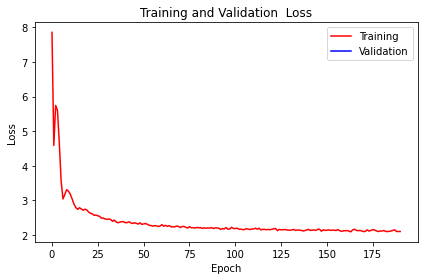

In [12]:
save_loss_plot(losses, Dir)

##  Measurement of avarage of auc, and time inference 

In [20]:
import time
import statistics as stat

Eva_final=dict()

l2_lambda=0.0001
args.l2_reg=l2_lambda
config["l2_reg"]= args.l2_reg

Accuracy=[]
T_inference=[]
Num_parm=[]
Model_size=[]

In [22]:
for i in range(10):
    
    print(f"This number of this stage:{i} ")
    # Run the main
    Eva=dict()
    test_auc, test_ap, t_inference= main(config)

    print(f"Test AUC: {test_auc}, AP: {test_ap}, Time inference:{t_inference}")
    
    ###

    
    # Print all measurment
    print(f"Our model with {l2_lambda} regularization has accuracy on test set={test_auc:.2f}%")
    #print(f"Our model with {l2_lambda} regularization has size={model_size/MiB:.2f} MiB")
    print(f"The time inference of our model with {l2_lambda} regularization is ={t_inference}") 
    #print(f"The number of parametrs of our model with {l2_lambda} regularization is:{num_parm}")



    #Update my Eva dictionary
    Eva.update({'Model accuracy': test_auc,
                'time inference': t_inference})


    Accuracy.append(Eva['Model accuracy'])
    T_inference.append(Eva['time inference'])
    #Num_parm.append(int(Eva['number parmameters of model']))
    #Model_size.append(int(Eva['size of model']))

     

This number of this stage:0 
Directories are set.
Directories are set.
Building the models for training and evaluation in NESS framework...
----------------------------------------Summary of the models:----------------------------------------
================================== NESS Architecture ==================================
GAEWrapper(
  (gae): GAE(
    (encoder): GNAEEncoder(
      (linear1): Linear(in_features=1433, out_features=32, bias=True)
      (propagate): APPNP(K=1, alpha=0)
    )
    (decoder): InnerProductDecoder()
  )
)

Done with saving models.
Done with saving models.
Done with saving models.
Epoch:[39] training loss:2.3815, X recon loss:0.9655, val auc:0.8971360002313173
Done with saving models.
Done with training...
Training time:  0.0 minutes, 48.75 seconds
Test AUC: 0.9270171221437122, AP: 0.935967614050779, Time inference:0.06249070167541504
Our model with 0.0001 regularization has accuracy on test set=0.93%
The time inference of our model with 0.0001 regulariza

----------------------------------------Summary of the models:----------------------------------------
================================== NESS Architecture ==================================
GAEWrapper(
  (gae): GAE(
    (encoder): GNAEEncoder(
      (linear1): Linear(in_features=1433, out_features=32, bias=True)
      (propagate): APPNP(K=1, alpha=0)
    )
    (decoder): InnerProductDecoder()
  )
)

Done with saving models.
Done with saving models.
Done with saving models.
Epoch:[39] training loss:2.3815, X recon loss:0.9655, val auc:0.8971360002313173
Done with saving models.
Done with training...
Training time:  0.0 minutes, 54.328125 seconds
Test AUC: 0.9270171221437122, AP: 0.9359675604783968, Time inference:0.06250905990600586
Our model with 0.0001 regularization has accuracy on test set=0.93%
The time inference of our model with 0.0001 regularization is =0.06250905990600586
This number of this stage:9 
Directories are set.
Directories are set.
Building the models for training an

<Figure size 432x288 with 0 Axes>

In [23]:
Accuracy

[0.9270171221437122,
 0.9270171221437122,
 0.9270171221437122,
 0.9270171221437122,
 0.9270171221437122,
 0.9270171221437122,
 0.9270171221437122,
 0.9270171221437122,
 0.9270171221437122,
 0.9270171221437122]

In [24]:
T_inference

[0.06249070167541504,
 0.05341196060180664,
 0.04687643051147461,
 0.06249260902404785,
 0.04687333106994629,
 0.053386688232421875,
 0.04687929153442383,
 0.06249189376831055,
 0.06250905990600586,
 0.06902289390563965]

In [25]:
Eva_final=dict()
std=dict()
print(100 * "=")

model_accuracy_mean = stat.mean(Accuracy)
model_accuracy_std =  stat.stdev(Accuracy)
Eva_final.update({'model accuracy':float(format(model_accuracy_mean, '.4f'))})
std.update({'Std of base model accuracy':float(format(model_accuracy_std, '.4f'))})

desc_model_accuracy = "{:.3f} ± {:.3f}".format(model_accuracy_mean,model_accuracy_std)
print(f"The mean of model accuracy:{desc_model_accuracy}")


print(100 * "=")
####Time inference    
t_model_mean =stat.mean(T_inference)
t_model_std =stat.stdev(T_inference)
Eva_final.update({'time inference of model':float(format(t_model_mean, '.6f'))})
std.update({'Std of time inference of model':float(format(t_model_std, '.6f'))})

desc_t_model = "{:.3f} ± {:.3f}".format(t_model_mean,t_model_std)
print(f"The mean of inference time is :{desc_t_model} ")

print(100 * "=")


The mean of model accuracy:0.927 ± 0.000
The mean of inference time is :0.057 ± 0.008 


In [26]:
Cora_Link_00001=Eva_final
print(Cora_Link_00001)

{'model accuracy': 0.927, 'time inference of model': 0.056643}


In [27]:
Cora_Link_00001=std
print(Cora_Link_00001)

{'Std of base model accuracy': 0.0, 'Std of time inference of model': 0.008148}
